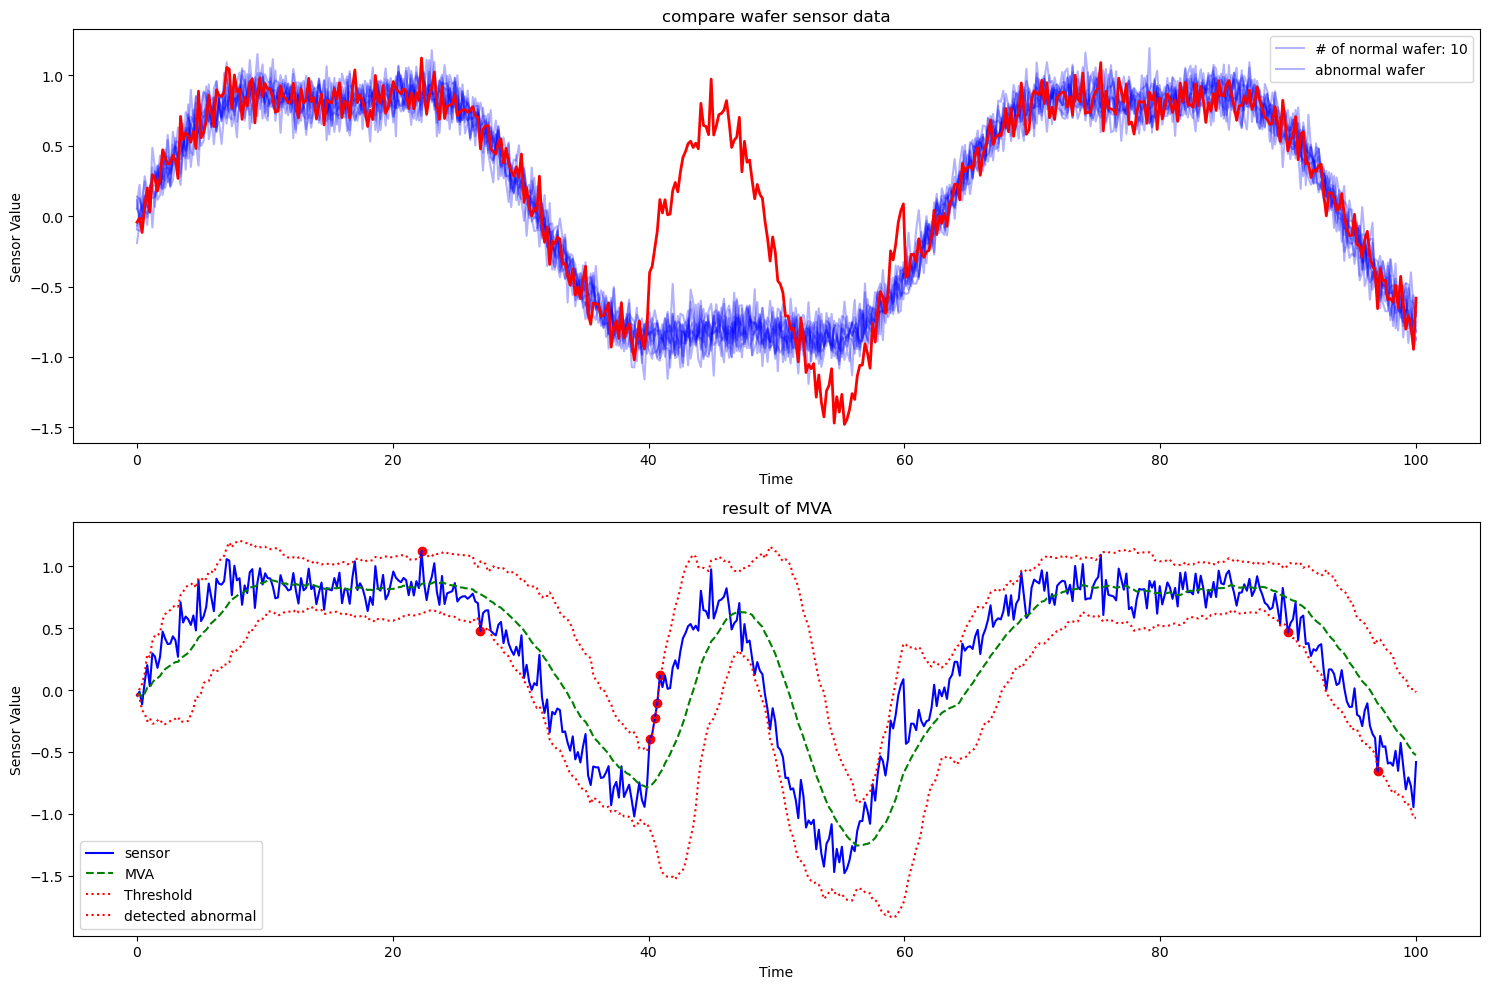

탐지된 이상 포인트 수: 8
전체 데이터 포인트 중 이상 비율: 1.60%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def detect_anomalies_ma(data, window_size=10, threshold=2.5):
    """
    이동 평균 기반 이상 탐지
    
    Parameters:
    -----------
    data : numpy array
        분석할 시계열 데이터
    window_size : int
        이동 평균 윈도우 크기
    threshold : float
        이상치로 판단할 표준편차 배수
        
    Returns:
    --------
    anomalies : numpy array
        이상치 여부 (True/False)
    """
    # 이동 평균 계산
    ma = np.array([np.mean(data[max(0, i-window_size):i+1]) 
                   for i in range(len(data))])
    
    # 이동 표준편차 계산
    mstd = np.array([np.std(data[max(0, i-window_size):i+1])
                     for i in range(len(data))])
    
    # 상한선과 하한선 계산
    upper_bound = ma + threshold * mstd
    lower_bound = ma - threshold * mstd
    
    # 이상치 탐지
    anomalies = (data > upper_bound) | (data < lower_bound)
    
    return anomalies, upper_bound, lower_bound, ma

# 예시 데이터 생성 (정상 웨이퍼 10개와 비정상 웨이퍼 1개)
np.random.seed(42)
time_points = np.linspace(0, 100, 500)
normal_pattern = np.sin(time_points * 0.1) + 0.2 * np.sin(time_points * 0.3)

# 정상 웨이퍼 데이터 (약간의 노이즈 포함)
normal_wafers = []
for i in range(10):
    noise = np.random.normal(0, 0.1, len(time_points))
    wafer_data = normal_pattern + noise
    normal_wafers.append(wafer_data)

# 비정상 웨이퍼 데이터 (특정 구간에 이상 패턴 포함)
abnormal_wafer = normal_pattern.copy()
# 특정 구간에 이상 패턴 추가
abnormal_wafer[200:300] += 1.0 * np.sin(np.linspace(0, 2*np.pi, 100)) + 0.5
noise = np.random.normal(0, 0.1, len(time_points))
abnormal_wafer += noise

# 시각화 및 이상 탐지
plt.figure(figsize=(15, 10))

# 정상 웨이퍼 데이터 시각화
plt.subplot(2, 1, 1)
for i, wafer in enumerate(normal_wafers):
    plt.plot(time_points, wafer, alpha=0.3, color='blue')
plt.plot(time_points, abnormal_wafer, color='red', linewidth=2)
plt.title('compare wafer sensor data')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.legend(['# of normal wafer: 10', 'abnormal wafer'])

# 이상 탐지 결과 시각화
plt.subplot(2, 1, 2)
anomalies, upper, lower, ma = detect_anomalies_ma(abnormal_wafer, window_size=20, threshold=2.5)
plt.plot(time_points, abnormal_wafer, color='blue')
plt.plot(time_points, ma, color='green', linestyle='--')
plt.plot(time_points, upper, color='red', linestyle=':')
plt.plot(time_points, lower, color='red', linestyle=':')
plt.scatter(time_points[anomalies], abnormal_wafer[anomalies], color='red', marker='o')
plt.title('result of MVA')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.legend(['sensor', 'MVA', 'Threshold', 'detected abnormal'])

plt.tight_layout()
plt.show()

print(f"탐지된 이상 포인트 수: {np.sum(anomalies)}")
print(f"전체 데이터 포인트 중 이상 비율: {np.sum(anomalies)/len(anomalies)*100:.2f}%")

C:\Users\HYKP\AppData\Local\Temp\ipykernel_14080\3800970983.py:165: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HYKP\AppData\Local\Temp\ipykernel_14080\3800970983.py:165: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HYKP\AppData\Local\Temp\ipykernel_14080\3800970983.py:165: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


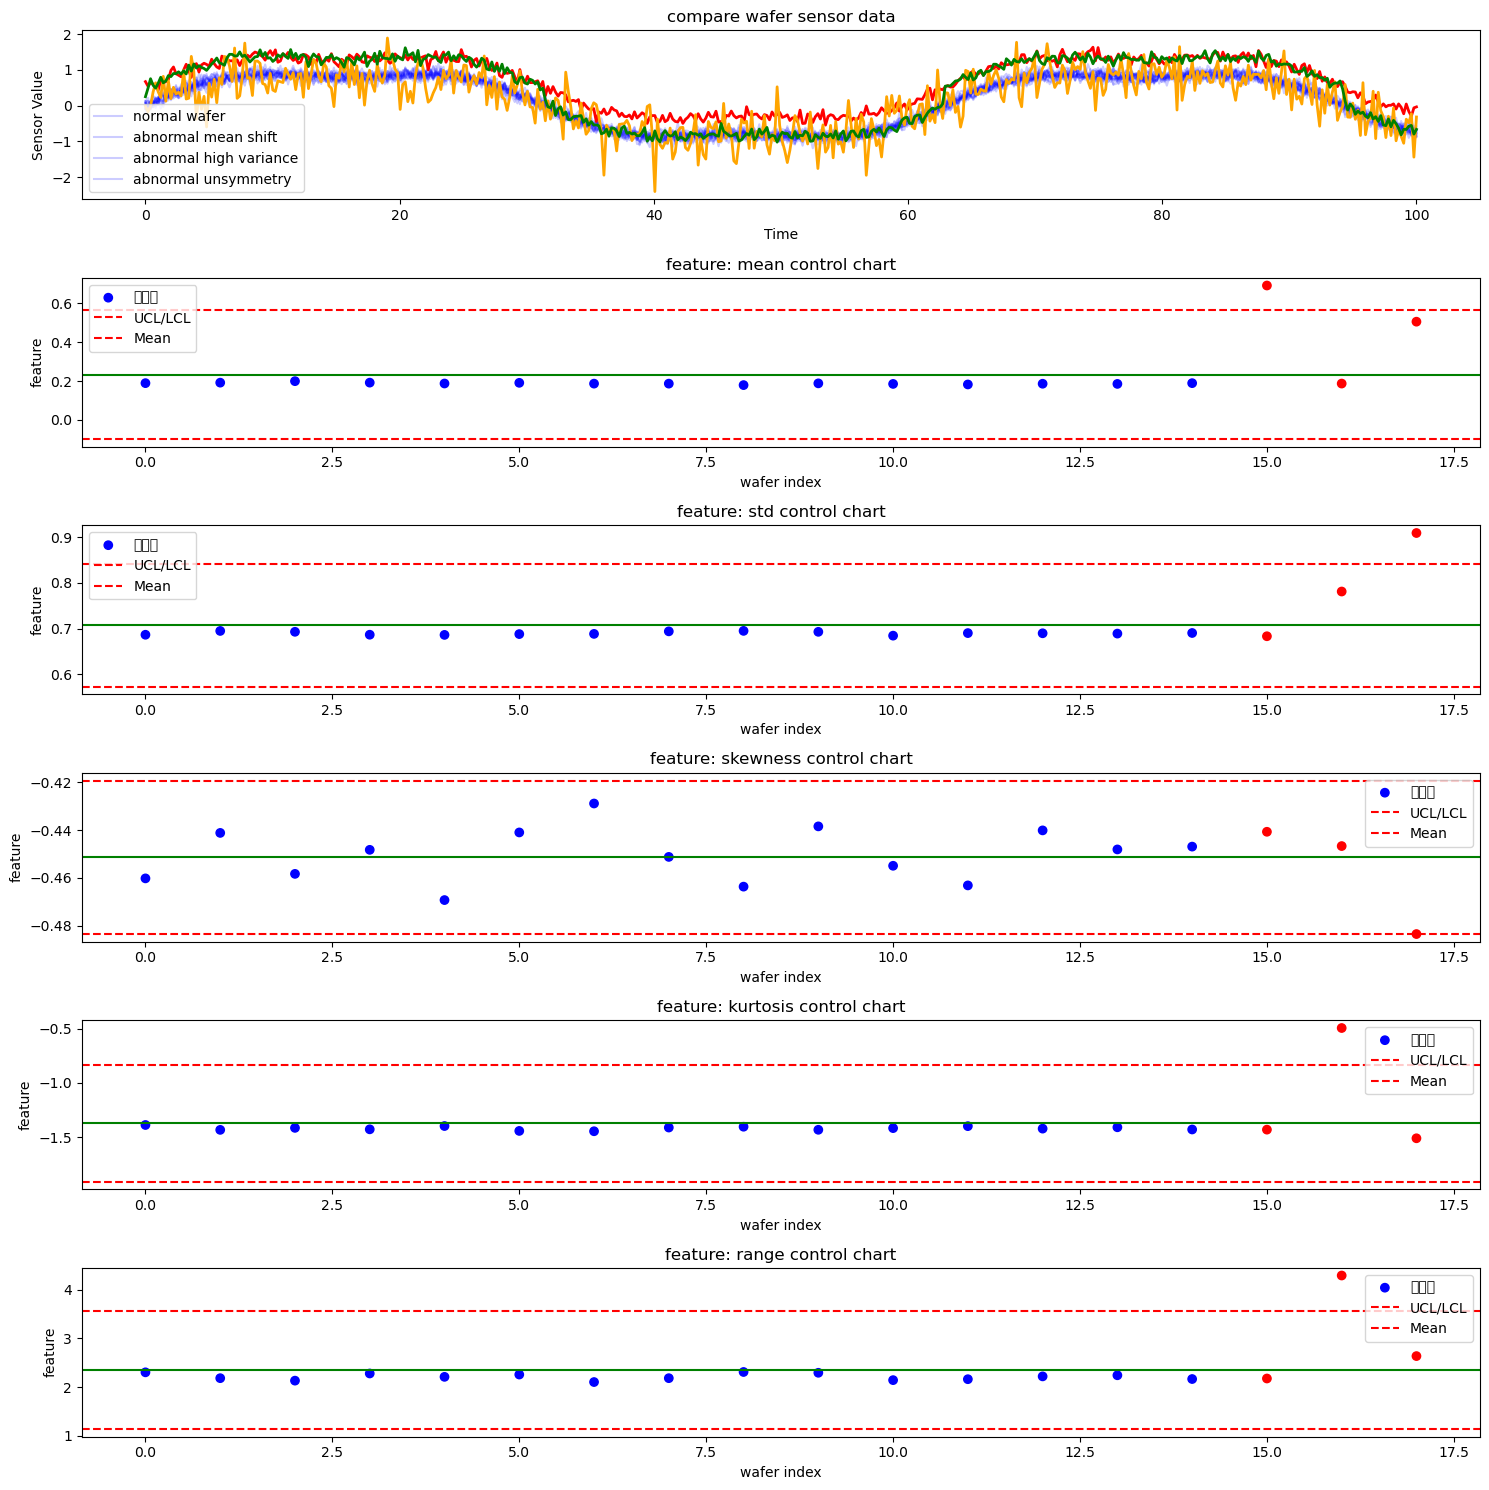

detected wafer: [15, 16, 17]
exceed comtrol limit:
- mean: [15]
- std: [17]
- skewness: [17]
- kurtosis: [16]
- range: [16]


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def extract_features(signal):
    """
    시계열 신호에서 통계적 특징 추출
    """
    features = {
        'mean': np.mean(signal),
        'std': np.std(signal),
        'max': np.max(signal),
        'min': np.min(signal),
        'median': np.median(signal),
        'skewness': stats.skew(signal),
        'kurtosis': stats.kurtosis(signal),
        'range': np.max(signal) - np.min(signal),
        'rms': np.sqrt(np.mean(np.square(signal))),
        'peak_to_peak': np.max(signal) - np.min(signal),
        'energy': np.sum(np.square(signal))
    }
    return features

def calculate_control_limits(feature_values, sigma_level=3):
    """
    특징값들에 대한 관리 한계 계산
    """
    mean = np.mean(feature_values)
    std = np.std(feature_values)
    
    ucl = mean + sigma_level * std  # 상한 관리선
    lcl = mean - sigma_level * std  # 하한 관리선
    
    return mean, lcl, ucl

def detect_anomalies_spc(wafers, features_to_use=['mean', 'std', 'skewness'], sigma_level=3):
    """
    SPC 기반 이상 웨이퍼 탐지
    
    Parameters:
    -----------
    wafers : list of numpy arrays
        분석할 웨이퍼 데이터 목록
    features_to_use : list of str
        사용할 특징 목록
    sigma_level : float
        관리 한계 설정을 위한 시그마 레벨
        
    Returns:
    --------
    anomalies : list of bool
        각 웨이퍼의 이상 여부
    feature_results : dict
        각 특징별 결과 정보
    """
    all_features = []
    
    # 각 웨이퍼에서 특징 추출
    for wafer in wafers:
        features = extract_features(wafer)
        all_features.append(features)
    
    # 결과 초기화
    anomalies = [False] * len(wafers)
    feature_results = {}
    
    # 각 특징별로 관리 한계 계산 및 이상 탐지
    for feature_name in features_to_use:
        feature_values = [features[feature_name] for features in all_features]
        mean, lcl, ucl = calculate_control_limits(feature_values, sigma_level)
        
        # 이상치 탐지 (관리 한계 벗어나는 경우)
        out_of_control = [(val > ucl) or (val < lcl) for val in feature_values]
        
        # 어느 하나라도 관리 한계를 벗어나면 이상으로 판단
        for i, is_out in enumerate(out_of_control):
            if is_out:
                anomalies[i] = True
        
        feature_results[feature_name] = {
            'values': feature_values,
            'mean': mean,
            'lcl': lcl,
            'ucl': ucl,
            'out_of_control': out_of_control
        }
    
    return anomalies, feature_results

# 예시 데이터 생성 (정상 웨이퍼 15개와 비정상 웨이퍼 3개)
np.random.seed(42)
time_points = np.linspace(0, 100, 500)
normal_pattern = np.sin(time_points * 0.1) + 0.2 * np.sin(time_points * 0.3)

# 정상 웨이퍼 데이터 (약간의 노이즈 포함)
wafers = []
for i in range(15):
    noise = np.random.normal(0, 0.1, len(time_points))
    wafer_data = normal_pattern + noise
    wafers.append(wafer_data)

# 비정상 웨이퍼 데이터 1 (평균 이동)
abnormal_wafer1 = normal_pattern + 0.5 + np.random.normal(0, 0.1, len(time_points))
wafers.append(abnormal_wafer1)

# 비정상 웨이퍼 데이터 2 (분산 증가)
abnormal_wafer2 = normal_pattern + np.random.normal(0, 0.4, len(time_points))
wafers.append(abnormal_wafer2)

# 비정상 웨이퍼 데이터 3 (비대칭성 증가)
abnormal_wafer3 = normal_pattern.copy()
# 비대칭성 증가를 위해 일부 영역만 값 증가
abnormal_wafer3[normal_pattern > 0] += 0.5
abnormal_wafer3 += np.random.normal(0, 0.1, len(time_points))
wafers.append(abnormal_wafer3)

# SPC 기반 이상 탐지
features_to_use = ['mean', 'std', 'skewness', 'kurtosis', 'range']
anomalies, feature_results = detect_anomalies_spc(wafers, features_to_use=features_to_use, sigma_level=2.5)

# 시각화
plt.figure(figsize=(15, 15))

# 모든 웨이퍼 데이터 시각화
plt.subplot(len(features_to_use) + 1, 1, 1)
for i, wafer in enumerate(wafers):
    if i < 15:  # 정상 웨이퍼
        plt.plot(time_points, wafer, alpha=0.2, color='blue')
    else:  # 비정상 웨이퍼
        plt.plot(time_points, wafer, linewidth=2, 
                 color='red' if i == 15 else 'orange' if i == 16 else 'green')
plt.title('compare wafer sensor data')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.legend(['normal wafer', 'abnormal mean shift', 
            'abnormal high variance', 'abnormal unsymmetry'])

# 각 특징별 관리 차트 시각화
for i, feature_name in enumerate(features_to_use):
    plt.subplot(len(features_to_use) + 1, 1, i + 2)
    
    result = feature_results[feature_name]
    values = result['values']
    lcl = result['lcl']
    ucl = result['ucl']
    mean = result['mean']
    out_of_control = result['out_of_control']
    
    # 특징값 그래프
    colors = ['blue' if i < 15 else 'red' for i in range(len(values))]
    for j in range(len(values)):
        if out_of_control[j]:
            colors[j] = 'red'
    
    plt.scatter(range(len(values)), values, color=colors)
    plt.axhline(y=ucl, color='r', linestyle='--', label='UCL')
    plt.axhline(y=lcl, color='r', linestyle='--', label='LCL')
    plt.axhline(y=mean, color='g', linestyle='-', label='Mean')
    
    plt.title(f'feature: {feature_name} control chart')
    plt.xlabel('wafer index')
    plt.ylabel('feature')
    plt.legend(['특징값', 'UCL/LCL', 'Mean'])

plt.tight_layout()
plt.show()

print("detected wafer:", [i for i, a in enumerate(anomalies) if a])
print("exceed comtrol limit:")
for feature_name in features_to_use:
    out_of_control = feature_results[feature_name]['out_of_control']
    print(f"- {feature_name}: {[i for i, o in enumerate(out_of_control) if o]}")

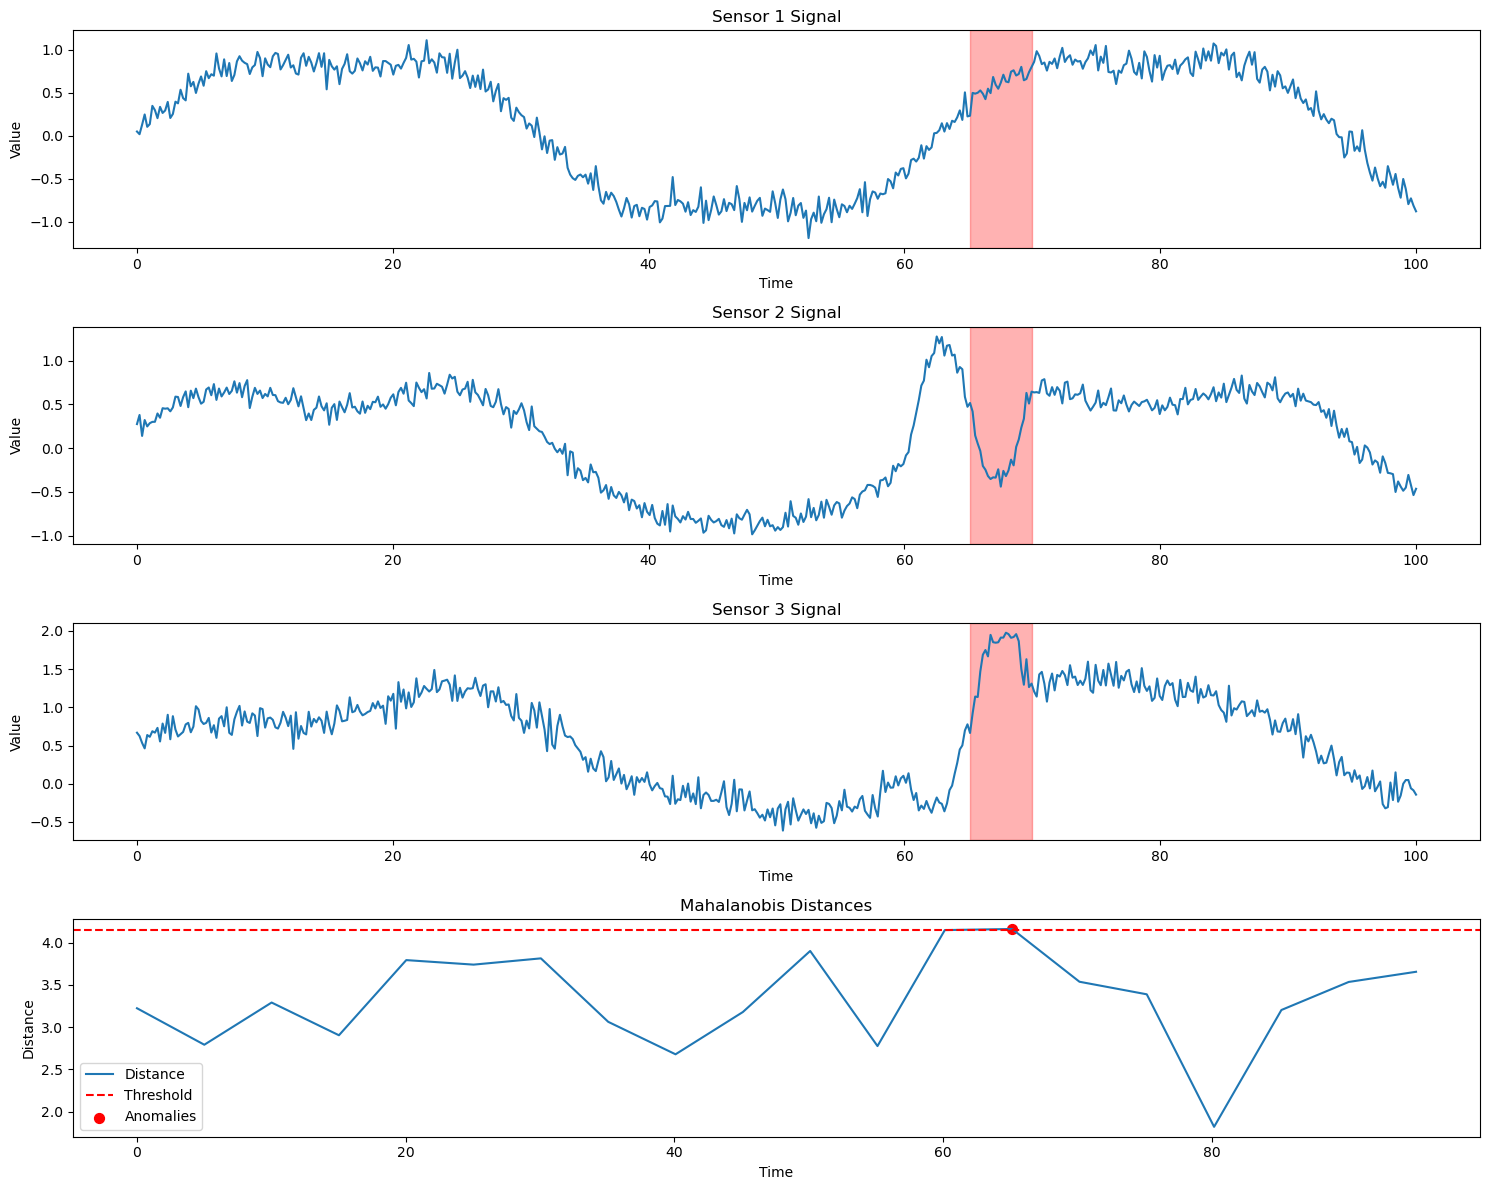

Number of detected anomalous segments: 1 out of 20
Threshold value: 4.15
Anomalous segment indices: [13]
Corresponding time points: [65.13026052]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy import stats

def extract_segment_features(signals, segment_size=50):
    """
    Extract features from segments of time series signals
    
    Parameters:
    -----------
    signals : list of numpy arrays
        List of time series signals
    segment_size : int
        Size of each segment
        
    Returns:
    --------
    features : numpy array
        Feature matrix where each row is a segment and each column is a feature
    """
    n_signals = len(signals)
    n_samples = len(signals[0])
    n_segments = n_samples // segment_size
    
    # Array to store features for each segment
    features = []
    
    # Extract features for each segment
    for i in range(n_segments):
        start_idx = i * segment_size
        end_idx = (i + 1) * segment_size
        
        segment_features = []
        for signal in signals:
            segment = signal[start_idx:end_idx]
            # Extract 4 features from each segment
            segment_features.extend([
                np.mean(segment),
                np.std(segment),
                stats.skew(segment),
                np.max(segment) - np.min(segment)
            ])
        
        features.append(segment_features)
    
    return np.array(features)

def mahalanobis_distance(x, data):
    """
    Calculate Mahalanobis distance between a point x and a distribution represented by data
    
    Parameters:
    -----------
    x : numpy array
        Point to calculate distance for
    data : numpy array
        Data points representing the distribution
        
    Returns:
    --------
    dist : float
        Mahalanobis distance
    """
    mean = np.mean(data, axis=0)
    cov = np.cov(data.T)
    
    # Check if covariance matrix is invertible
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        # Add a small regularization term for numerical stability
        cov += np.eye(cov.shape[0]) * 1e-5
        inv_cov = np.linalg.inv(cov)
    
    dist = mahalanobis(x, mean, inv_cov)
    return dist

def detect_anomalies_mahalanobis(signals, segment_size=50, threshold_percentile=95):
    """
    Detect anomalies in time series data using Mahalanobis distance
    
    Parameters:
    -----------
    signals : list of numpy arrays
        List of time series signals to analyze
    segment_size : int
        Size of each segment for feature extraction
    threshold_percentile : float
        Percentile value for threshold determination
        
    Returns:
    --------
    anomaly_segments : numpy array
        Boolean array indicating anomalous segments
    distances : numpy array
        Mahalanobis distances for each segment
    threshold : float
        Threshold value used for anomaly detection
    """
    # Extract features from segments
    features = extract_segment_features(signals, segment_size)
    
    # Calculate Mahalanobis distance for each segment
    distances = np.array([mahalanobis_distance(feature, features) for feature in features])
    
    # Set threshold based on percentile
    threshold = np.percentile(distances, threshold_percentile)
    
    # Detect anomalous segments
    anomaly_segments = distances > threshold
    
    return anomaly_segments, distances, threshold

# Generate example data (3 sensor signals)
np.random.seed(42)
time_points = np.linspace(0, 100, 500)

# Base patterns with correlations between signals
signal1_base = np.sin(time_points * 0.1) + 0.2 * np.sin(time_points * 0.3)
signal2_base = 0.8 * signal1_base + 0.2 * np.cos(time_points * 0.2)
signal3_base = 0.7 * signal1_base - 0.3 * np.sin(time_points * 0.15) + 0.5

# Add noise
signal1 = signal1_base + np.random.normal(0, 0.1, len(time_points))
signal2 = signal2_base + np.random.normal(0, 0.08, len(time_points))
signal3 = signal3_base + np.random.normal(0, 0.12, len(time_points))

# Add anomalous region (break correlation)
abnormal_start = 300
abnormal_end = 350
signal2[abnormal_start:abnormal_end] += 1.0 * np.sin(np.linspace(0, 2*np.pi, abnormal_end-abnormal_start))
signal3[abnormal_start:abnormal_end] -= 0.8 * np.sin(np.linspace(0, 2*np.pi, abnormal_end-abnormal_start))

# Bundle signals
signals = [signal1, signal2, signal3]

# Detect anomalies using Mahalanobis distance
segment_size = 25
anomaly_segments, distances, threshold = detect_anomalies_mahalanobis(
    signals, segment_size=segment_size, threshold_percentile=95)

# Visualization
plt.figure(figsize=(15, 12))

# Plot sensor signals
for i, signal in enumerate(signals):
    plt.subplot(4, 1, i+1)
    plt.plot(time_points, signal)
    
    # Highlight anomalous regions
    n_segments = len(time_points) // segment_size
    for j in range(n_segments):
        if anomaly_segments[j]:
            start_idx = j * segment_size
            end_idx = min((j + 1) * segment_size, len(time_points))
            plt.axvspan(time_points[start_idx], time_points[end_idx-1], 
                       alpha=0.3, color='red')
    
    plt.title(f'Sensor {i+1} Signal')
    plt.xlabel('Time')
    plt.ylabel('Value')

# Plot Mahalanobis distances
plt.subplot(4, 1, 4)
segment_times = np.array([time_points[i * segment_size] for i in range(len(distances))])
plt.plot(segment_times, distances)
plt.axhline(y=threshold, color='r', linestyle='--')

# Highlight anomalous segments
for j in range(len(anomaly_segments)):
    if anomaly_segments[j]:
        plt.scatter(segment_times[j], distances[j], color='red', s=50)

plt.title('Mahalanobis Distances')
plt.xlabel('Time')
plt.ylabel('Distance')
plt.legend(['Distance', 'Threshold', 'Anomalies'])

plt.tight_layout()
plt.show()

# Print results
n_anomalies = np.sum(anomaly_segments)
print(f"Number of detected anomalous segments: {n_anomalies} out of {len(anomaly_segments)}")
print(f"Threshold value: {threshold:.2f}")

# Print anomalous segment indices
anomaly_indices = np.where(anomaly_segments)[0]
print(f"Anomalous segment indices: {anomaly_indices}")
print(f"Corresponding time points: {segment_times[anomaly_indices]}")

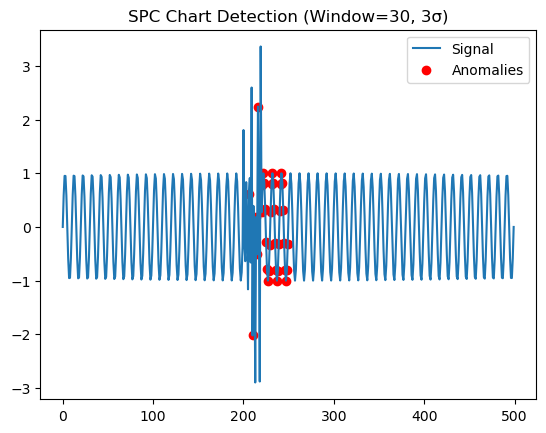

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def spc_detection(data, window=30, sigma=3):
    means = [np.mean(data[i:i+window]) for i in range(len(data)-window)]
    ranges = [np.ptp(data[i:i+window]) for i in range(len(data)-window)]
    
    ucl_mean = np.mean(means) + sigma*np.std(means)
    lcl_mean = np.mean(means) - sigma*np.std(means)
    ucl_range = np.mean(ranges) + sigma*np.std(ranges)
    
    anomalies = []
    for i in range(len(means)):
        if means[i] > ucl_mean or means[i] < lcl_mean:
            anomalies.append(i+window)
        if ranges[i] > ucl_range:
            anomalies.append(i+window)
    return sorted(set(anomalies))

# 5Hz 사인파에 임의 이상 추가
t = np.linspace(0, 10, 500)
normal = np.sin(2*np.pi*5*t)
abnormal = normal.copy()
abnormal[200:220] += np.random.normal(0, 2, 20)
detections = spc_detection(abnormal)

plt.plot(abnormal, label='Signal')
plt.scatter(detections, abnormal[detections], c='r', label='Anomalies')
plt.legend()
plt.title('SPC Chart Detection (Window=30, 3σ)')
plt.show()

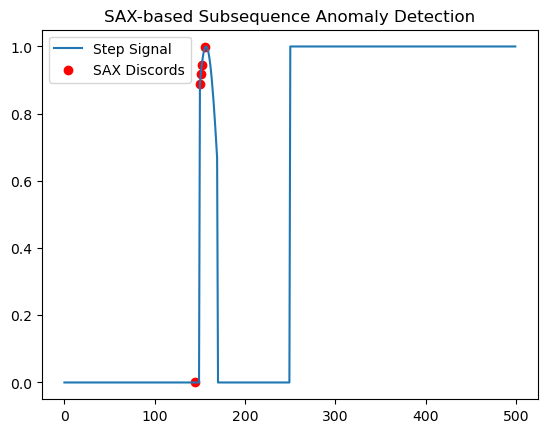

In [33]:
import warnings
warnings.filterwarnings(action='ignore')

from tslearn.piecewise import SymbolicAggregateApproximation

def sax_discord(data, window=50, sax_dim=8, n_discords=5):
    sax = SymbolicAggregateApproximation(n_segments=sax_dim)
    data_sax = sax.fit_transform(data.reshape(1, -1))
    
    discords = []
    for i in range(len(data)-window):
        subseq = data[i:i+window]
        subseq_sax = sax.transform(subseq.reshape(1, -1))
        distance = np.linalg.norm(data_sax - subseq_sax)
        discords.append((i, distance))
    
    return sorted(discords, key=lambda x: -x[1])[:n_discords]

# 계단형 패턴에 이상 서브시퀀스 삽입
t = np.linspace(0, 5, 500)
step = np.zeros_like(t)
step[t>=2.5] = 1
step[150:170] = np.sin(t[150:170]*5)**2  # 이상 패턴

discords = sax_discord(step)
indices = [d[0] for d in discords]

plt.plot(step, label='Step Signal')
plt.scatter(indices, step[indices], c='r', label='SAX Discords')
plt.title('SAX-based Subsequence Anomaly Detection')
plt.legend()
plt.show()

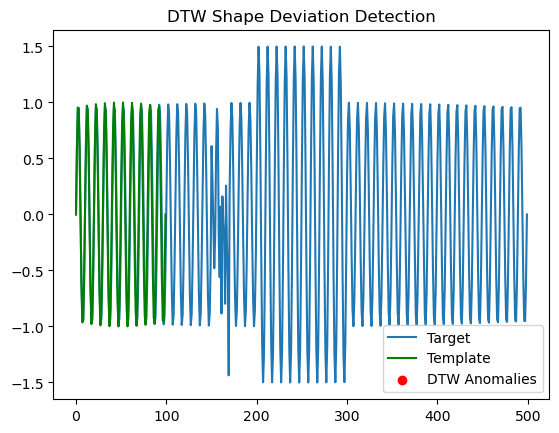

In [34]:
from tslearn.metrics import dtw
from scipy.spatial.distance import cdist

def dtw_shape_detection(template, target, threshold):
    distances = []
    for i in range(len(target)-len(template)):
        segment = target[i:i+len(template)]
        distances.append(dtw(template, segment))
    
    anomalies = np.where(np.array(distances) > threshold)[0]
    return anomalies

# 템플릿: 정상 파형 (10Hz 사인파)
t_template = np.linspace(0, 1, 100)
template = np.sin(2*np.pi*10*t_template)

# 타겟: 중첩 왜곡 포함 신호
t_target = np.linspace(0, 5, 500)
target = np.sin(2*np.pi*10*t_target)
target[200:300] *= 1.5  # 진폭 변형
target[150:170] = np.random.normal(0, 0.5, 20)  # 임펄스 노이즈

anomalies = dtw_shape_detection(template, target, threshold=15)

plt.plot(target, label='Target')
plt.plot(range(len(template)), template, 'g', label='Template')
plt.scatter(anomalies, target[anomalies], c='r', label='DTW Anomalies')
plt.legend()
plt.title('DTW Shape Deviation Detection')
plt.show()

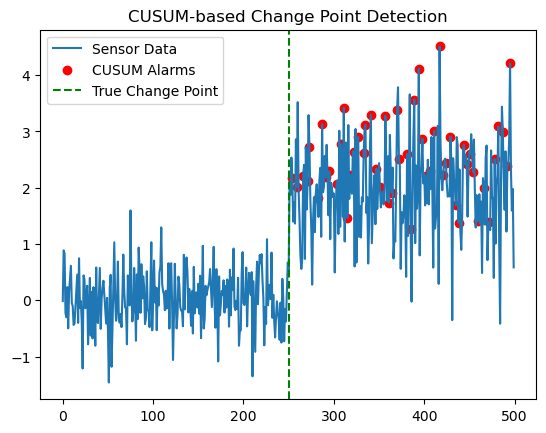

In [35]:
def cusum_detection(data, mu0=0, k=0.5, h=5):
    S = [0]
    alarms = []
    for i, x in enumerate(data):
        S.append(max(0, S[-1] + (x - mu0 - k)))
        if S[-1] > h:
            alarms.append(i)
            S[-1] = 0  # Reset accumulator
    return alarms

# 테스트 신호 생성
t = np.linspace(0, 10, 500)
signal = np.concatenate([np.random.normal(0, 0.5, 250), 
                        np.random.normal(2, 0.8, 250)])

detections = cusum_detection(signal, k=1, h=4)

plt.plot(signal, label='Sensor Data')
plt.scatter(detections, signal[detections], c='r', label='CUSUM Alarms')
plt.axvline(250, color='g', linestyle='--', label='True Change Point')
plt.legend()
plt.title('CUSUM-based Change Point Detection')
plt.show()